Running Daily Extreme-Value Tournaments...


Daily Iterations: 100%|██████████| 461/461 [00:26<00:00, 17.30it/s]



--- Project 2: Reversal Performance ($10,000 Portfolio) ---


,Strategy,Final Equity ($),Total Profit ($),Sharpe,Accuracy (%)
0,Dynamic ADF (Extreme Z),"$10,409.07",$409.07,0.56,53.41%
1,Cross-Sectional Momentum Fade,"$12,862.66","$2,862.66",0.75,49.89%
2,SPY Intraday,"$10,458.90",$458.90,0.23,52.69%



--- Side Output: Top 5 Extreme Movers (Tail) ---


,Date,Strategy,Stock,Prior Day Return (%),Action Taken
2295,2026-02-19,Cross-Sectional Reversal,GPN,16.47,Short
2296,2026-02-19,Cross-Sectional Reversal,CHRW,4.78,Short
2297,2026-02-19,Cross-Sectional Reversal,J,3.69,Short
2298,2026-02-19,Cross-Sectional Reversal,TPL,3.35,Short
2299,2026-02-19,Cross-Sectional Reversal,IT,3.17,Short
2300,2026-02-20,Cross-Sectional Reversal,TPL,10.40,Short
2301,2026-02-20,Cross-Sectional Reversal,EIX,4.25,Short
2302,2026-02-20,Cross-Sectional Reversal,SW,-3.97,Long
2303,2026-02-20,Cross-Sectional Reversal,ON,-3.64,Long
2304,2026-02-20,Cross-Sectional Reversal,IP,-3.34,Long


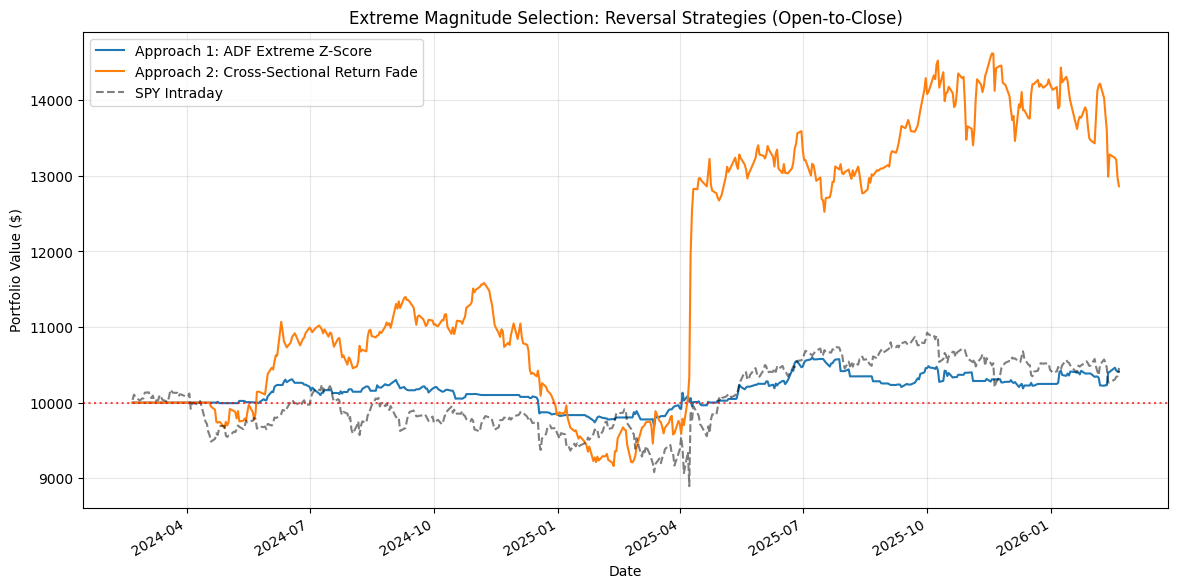

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import warnings
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ==========================================
# 1. SETUP & DATA ACQUISITION
# ==========================================
tickers = ["PPG", "DG", "TPL", "RF", "CHD", "EIX", "LH", "DRI", "CDW", "WAT",
           "L", "DVN", "TYL", "SBAC", "ON", "IP", "WST", "LULU", "DLTR", "NI",
           "ZBH", "NVR", "KEY", "DGX", "RL", "SW", "TRMB", "BG", "GPN", "IT",
           "J", "PFG", "CPAY", "INCY", "TSN", "AMCR", "CHRW", "CTRA", "GDDY", "SPY"]

print("Downloading Data...")
raw_data = yf.download(tickers, period="2y", interval="1d", auto_adjust=True, progress=False)
prices_close = raw_data['Close'].dropna(axis=1)
prices_open = raw_data['Open'][prices_close.columns]

# Intraday returns for PnL calculation (Open to Close)
ret_intra = (prices_close - prices_open) / prices_open
asset_list = [c for c in prices_close.columns if c != 'SPY']

# Daily Close-to-Close returns for Approach 2 Ranking
ret_daily = prices_close.pct_change()

# ==========================================
# 2. DYNAMIC CROSS-SECTIONAL TOURNAMENT
# ==========================================
final_alloc_adf = pd.DataFrame(0.0, index=prices_close.index, columns=asset_list)
final_alloc_cross = pd.DataFrame(0.0, index=prices_close.index, columns=asset_list)
side_output_data = []

start_idx = 40
print("Running Daily Extreme-Value Tournaments...")

for t in tqdm(range(start_idx, len(prices_close)-1), desc="Daily Iterations"):
    today = prices_close.index[t]
    tomorrow = prices_close.index[t+1]

    # ---------------------------------------------------------
    # APPROACH 1: CLASSICAL (ADF + Extreme Z-Score Rank)
    # ---------------------------------------------------------
    stationary_z = {}
    for col in asset_list:
        window = prices_close[col].iloc[t-30:t+1].values
        try:
            # Check stationarity
            adf_stat, p_val, _, _, _, _ = adfuller(window, maxlag=1)
            if p_val < 0.05:
                mean = np.mean(window)
                std = np.std(window)
                z_score = (window[-1] - mean) / std
                stationary_z[col] = z_score
        except:
            pass

    # Rank the stationary stocks by Absolute Z-Score
    if stationary_z:
        # Sort dictionary by absolute value, descending
        sorted_z = sorted(stationary_z.items(), key=lambda item: abs(item[1]), reverse=True)
        top_5_adf = sorted_z[:5]

        for stock, z_val in top_5_adf:
            # Only trade if the stretch is statistically significant (> 1.0 standard dev)
            if z_val > 1.0:
                final_alloc_adf.at[tomorrow, stock] = -0.20 # Short the peak
            elif z_val < -1.0:
                final_alloc_adf.at[tomorrow, stock] = 0.20  # Buy the dip

    # ---------------------------------------------------------
    # APPROACH 2: CROSS-SECTIONAL RETURN REVERSAL (Your Logic)
    # ---------------------------------------------------------
    # Get the % returns of all stocks for today
    todays_returns = ret_daily.iloc[t][asset_list]

    # Rank by absolute magnitude to find the Top 5 craziest movers
    abs_returns = todays_returns.abs()
    top_5_cross = abs_returns.nlargest(5).index

    for stock in top_5_cross:
        ret_val = todays_returns[stock]

        # Apply Logic: Fade the extreme move
        if ret_val > 0:
            action = -0.20 # It went UP -> We go SHORT tomorrow
        elif ret_val < 0:
            action = 0.20  # It went DOWN -> We go LONG tomorrow
        else:
            action = 0

        final_alloc_cross.at[tomorrow, stock] = action

        # Log side output for transparency
        side_output_data.append({
            "Date": tomorrow.date(),
            "Strategy": "Cross-Sectional Reversal",
            "Stock": stock,
            "Prior Day Return (%)": round(ret_val * 100, 2),
            "Action Taken": "Short" if action < 0 else "Long"
        })

# ==========================================
# 3. PERFORMANCE ANALYTICS & PLOTTING
# ==========================================
port_ret_adf = (final_alloc_adf * ret_intra[asset_list]).sum(axis=1)
port_ret_cross = (final_alloc_cross * ret_intra[asset_list]).sum(axis=1)

def calc_metrics_usd(returns, name, initial_capital=10000):
    equity_curve = initial_capital * (1 + returns).cumprod()
    active_rets = returns[returns != 0]
    total_profit = equity_curve.iloc[-1] - initial_capital
    sharpe = (active_rets.mean() / active_rets.std()) * np.sqrt(252) if len(active_rets) > 1 else 0
    acc = (active_rets > 0).sum() / len(active_rets) if not active_rets.empty else 0

    return {
        "Strategy": name,
        "Final Equity ($)": f"${equity_curve.iloc[-1]:,.2f}",
        "Total Profit ($)": f"${total_profit:,.2f}",
        "Sharpe": round(sharpe, 2),
        "Accuracy (%)": f"{acc * 100:.2f}%"
    }, equity_curve

m_adf, eq_adf = calc_metrics_usd(port_ret_adf, "Dynamic ADF (Extreme Z)")
m_cross, eq_cross = calc_metrics_usd(port_ret_cross, "Cross-Sectional Momentum Fade")
m_spy, eq_spy = calc_metrics_usd(ret_intra['SPY'], "SPY Intraday")

print("\n\n--- Project 2: Reversal Performance ($10,000 Portfolio) ---")
display(pd.DataFrame([m_adf, m_cross, m_spy]))

print("\n--- Side Output: Top 5 Extreme Movers (Tail) ---")
df_side_output = pd.DataFrame(side_output_data)
display(df_side_output.tail(10))

# Plotting
plt.figure(figsize=(14,7))
eq_adf.plot(label="Approach 1: ADF Extreme Z-Score")
eq_cross.plot(label="Approach 2: Cross-Sectional Return Fade")
eq_spy.plot(label="SPY Intraday", alpha=0.5, color='black', linestyle='--')
plt.axhline(10000, color='red', linestyle=':', alpha=0.7)
plt.title("Extreme Magnitude Selection: Reversal Strategies (Open-to-Close)")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Running Daily Extreme-Value Tournaments (Grid Search)...


Daily Iterations: 100%|██████████| 461/461 [00:27<00:00, 16.70it/s]



--- Project 2: Reversal Grid Search Results ---


,Strategy,Final Equity ($),Total Profit ($),Sharpe,Accuracy (%)
0,Cross_Concentrated,"$17,783.12","$7,783.12",1.30,53.36%
1,Cross_Base,"$12,862.66","$2,862.66",0.75,49.89%
2,Cross_Broad,"$10,726.90",$726.90,0.32,50.11%
3,ADF_Aggressive,"$10,409.07",$409.07,0.56,53.41%
4,ADF_Base,"$10,052.93",$52.93,0.19,50.40%
5,ADF_Strict,"$9,882.40",$-117.60,-0.90,50.00%
6,SPY Intraday,"$10,458.90",$458.90,0.23,52.69%


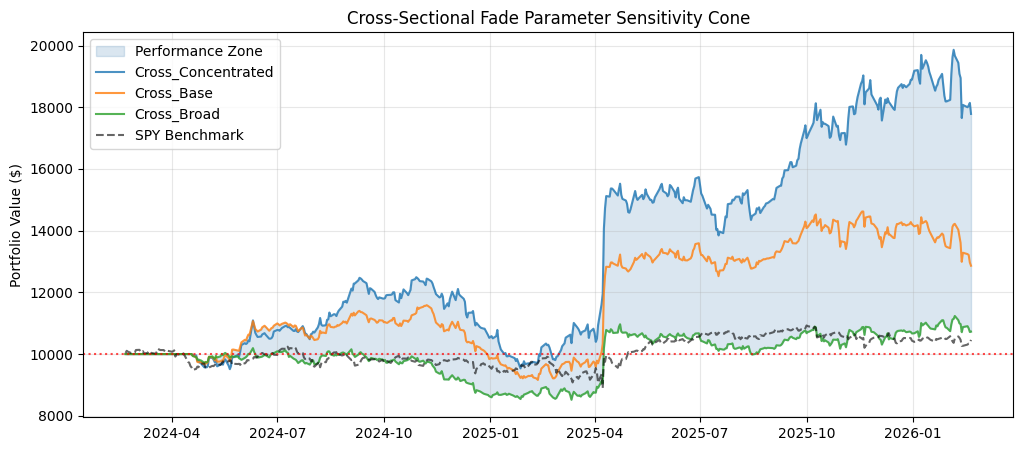

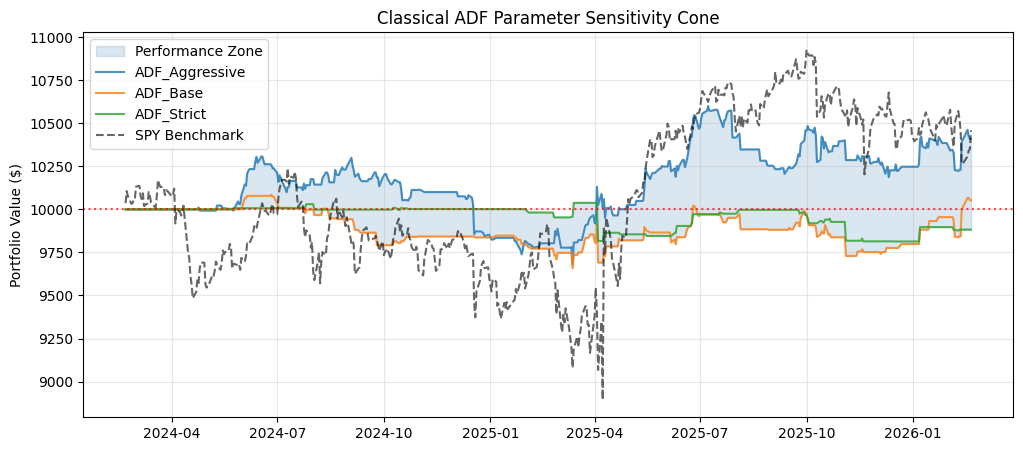


🏆 Winning Strategy Selected for Monte Carlo: Cross_Concentrated


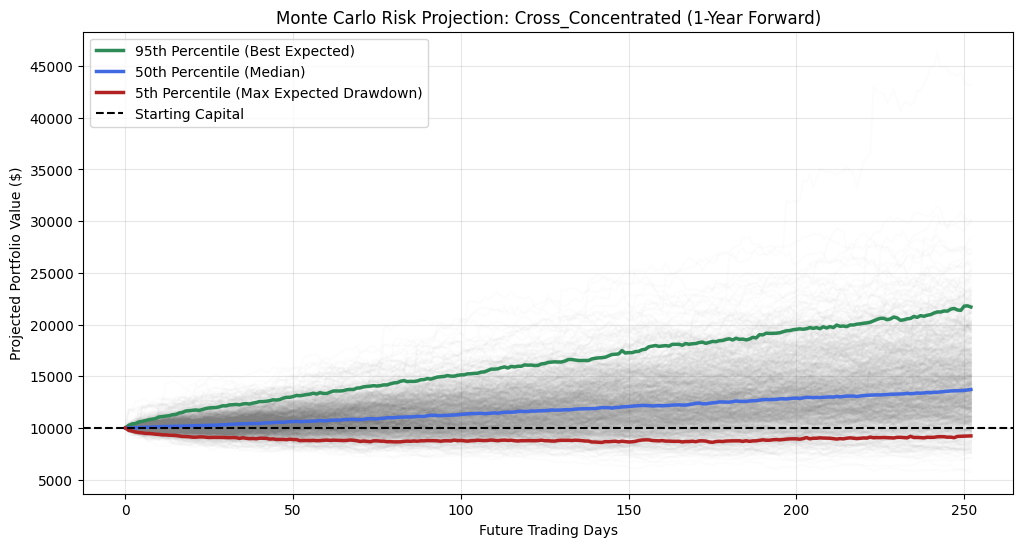


--- Monte Carlo Forward Risk Analytics (252 Days) ---
Median Expected Ending Equity: $13,716.66
Absolute Risk Limit (5th Pct): $9,233.44 <- System shutdown threshold


In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import warnings
from tqdm import tqdm

warnings.filterwarnings("ignore")

# ==========================================
# 1. SETUP & DATA ACQUISITION
# ==========================================
tickers = ["PPG", "DG", "TPL", "RF", "CHD", "EIX", "LH", "DRI", "CDW", "WAT",
           "L", "DVN", "TYL", "SBAC", "ON", "IP", "WST", "LULU", "DLTR", "NI",
           "ZBH", "NVR", "KEY", "DGX", "RL", "SW", "TRMB", "BG", "GPN", "IT",
           "J", "PFG", "CPAY", "INCY", "TSN", "AMCR", "CHRW", "CTRA", "GDDY", "SPY"]

print("Downloading Data...")
raw_data = yf.download(tickers, period="2y", interval="1d", auto_adjust=True, progress=False)
prices_close = raw_data['Close'].dropna(axis=1)
prices_open = raw_data['Open'][prices_close.columns]

# Intraday returns for PnL
ret_intra = (prices_close - prices_open) / prices_open
asset_list = [c for c in prices_close.columns if c != 'SPY']

# Daily Returns for Cross-Sectional Ranking
ret_daily = prices_close.pct_change()

# ==========================================
# 2. SCENARIO PARAMETERS (Grid)
# ==========================================
cross_scenarios = {
    "Cross_Concentrated": {"top_n": 3, "weight": 0.333},
    "Cross_Base": {"top_n": 5, "weight": 0.200},
    "Cross_Broad": {"top_n": 10, "weight": 0.100}
}

adf_scenarios = {
    "ADF_Aggressive": {"z_thresh": 1.0},
    "ADF_Base": {"z_thresh": 1.5},
    "ADF_Strict": {"z_thresh": 2.0}
}

all_scenarios = list(cross_scenarios.keys()) + list(adf_scenarios.keys())
allocations = {name: pd.DataFrame(0.0, index=prices_close.index, columns=asset_list) for name in all_scenarios}

# ==========================================
# 3. DYNAMIC TOURNAMENT ENGINE
# ==========================================
start_idx = 40
print("Running Daily Extreme-Value Tournaments (Grid Search)...")

for t in tqdm(range(start_idx, len(prices_close)-1), desc="Daily Iterations"):
    today = prices_close.index[t]
    tomorrow = prices_close.index[t+1]

    # --- A. CLASSICAL ADF LOGIC ---
    stationary_z = {}
    for col in asset_list:
        window = prices_close[col].iloc[t-30:t+1].values
        try:
            adf_stat, p_val, _, _, _, _ = adfuller(window, maxlag=1)
            if p_val < 0.05:
                mean = np.mean(window)
                std = np.std(window)
                z_score = (window[-1] - mean) / std
                stationary_z[col] = z_score
        except:
            pass

    # Sort dictionary by absolute value, descending
    sorted_z = sorted(stationary_z.items(), key=lambda item: abs(item[1]), reverse=True)

    # Apply ADF scenarios
    for name, params in adf_scenarios.items():
        thresh = params["z_thresh"]
        # Take Top 5 that meet the specific threshold constraint
        valid_stocks = [(s, z) for s, z in sorted_z if abs(z) > thresh][:5]
        for stock, z_val in valid_stocks:
            allocations[name].at[tomorrow, stock] = -0.20 if z_val > 0 else 0.20

    # --- B. CROSS-SECTIONAL LOGIC ---
    todays_returns = ret_daily.iloc[t][asset_list]
    abs_returns = todays_returns.abs()

    # Apply Cross-Sectional scenarios
    for name, params in cross_scenarios.items():
        n = params["top_n"]
        w = params["weight"]
        top_n_stocks = abs_returns.nlargest(n).index

        for stock in top_n_stocks:
            ret_val = todays_returns[stock]
            if ret_val > 0:
                allocations[name].at[tomorrow, stock] = -w # Short
            elif ret_val < 0:
                allocations[name].at[tomorrow, stock] = w  # Long

# ==========================================
# 4. PERFORMANCE ANALYTICS
# ==========================================
def calc_metrics_usd(returns, name, initial_capital=10000):
    equity_curve = initial_capital * (1 + returns).cumprod()
    active_rets = returns[returns != 0]
    total_profit = equity_curve.iloc[-1] - initial_capital
    sharpe = (active_rets.mean() / active_rets.std()) * np.sqrt(252) if len(active_rets) > 1 else 0
    acc = (active_rets > 0).sum() / len(active_rets) if not active_rets.empty else 0
    return {
        "Strategy": name, "Final Equity ($)": f"${equity_curve.iloc[-1]:,.2f}",
        "Total Profit ($)": f"${total_profit:,.2f}", "Sharpe": round(sharpe, 2),
        "Accuracy (%)": f"{acc * 100:.2f}%"
    }, equity_curve

results_list = []
equity_curves = {}

# Calculate for all strategies
for name in all_scenarios:
    port_ret = (allocations[name] * ret_intra[asset_list]).sum(axis=1)
    metrics, eq_curve = calc_metrics_usd(port_ret, name)
    results_list.append(metrics)
    equity_curves[name] = eq_curve

# Benchmark
spy_metrics, spy_eq = calc_metrics_usd(ret_intra['SPY'], "SPY Intraday")
results_list.append(spy_metrics)
equity_curves["SPY Intraday"] = spy_eq

print("\n\n--- Project 2: Reversal Grid Search Results ---")
display(pd.DataFrame(results_list))

# ==========================================
# 5. THE "DARK ZONE" PLOTS
# ==========================================

def plot_shaded_scenarios(scenario_keys, title_prefix):
    subset_curves = {k: equity_curves[k] for k in scenario_keys}
    df_curves = pd.DataFrame(subset_curves)
    plt.figure(figsize=(12, 5))
    plt.fill_between(df_curves.index, df_curves.min(axis=1), df_curves.max(axis=1), color='steelblue', alpha=0.2, label='Performance Zone')
    for name in df_curves.columns:
        plt.plot(df_curves.index, df_curves[name], alpha=0.8, linewidth=1.5, label=name)
    plt.plot(equity_curves["SPY Intraday"].index, equity_curves["SPY Intraday"], color='black', linestyle='--', alpha=0.6, label='SPY Benchmark')
    plt.axhline(10000, color='red', linestyle=':', alpha=0.7)
    plt.title(f"{title_prefix} Parameter Sensitivity Cone")
    plt.ylabel("Portfolio Value ($)")
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

plot_shaded_scenarios(cross_scenarios.keys(), "Cross-Sectional Fade")
plot_shaded_scenarios(adf_scenarios.keys(), "Classical ADF")

# ==========================================
# 6. MONTE CARLO BOOTSTRAP (ON THE WINNER)
# ==========================================

# Find the winner (excluding SPY)
best_strategy = max(results_list[:-1], key=lambda x: float(x['Final Equity ($)'].replace('$', '').replace(',', '')))['Strategy']
print(f"\n🏆 Winning Strategy Selected for Monte Carlo: {best_strategy}")

best_alloc_df = allocations[best_strategy]
winning_daily_returns = (best_alloc_df * ret_intra[asset_list]).sum(axis=1)

def run_monte_carlo(daily_returns, initial_capital=10000, num_simulations=1000, trading_days=252):
    active_returns = daily_returns[daily_returns != 0].dropna().values
    simulation_df = np.zeros((trading_days + 1, num_simulations))
    simulation_df[0, :] = initial_capital
    for x in range(num_simulations):
        simulated_rets = np.random.choice(active_returns, size=trading_days, replace=True)
        simulation_df[1:, x] = initial_capital * (1 + simulated_rets).cumprod()
    sim_df = pd.DataFrame(simulation_df)
    return sim_df, sim_df.quantile(0.05, axis=1), sim_df.quantile(0.50, axis=1), sim_df.quantile(0.95, axis=1)

sim_data, p5, p50, p95 = run_monte_carlo(winning_daily_returns)

plt.figure(figsize=(12, 6))
plt.plot(sim_data, color='gray', alpha=0.02)
plt.plot(p95, color='seagreen', linewidth=2.5, label='95th Percentile (Best Expected)')
plt.plot(p50, color='royalblue', linewidth=2.5, label='50th Percentile (Median)')
plt.plot(p5, color='firebrick', linewidth=2.5, label='5th Percentile (Max Expected Drawdown)')
plt.axhline(10000, color='black', linestyle='--', label='Starting Capital')
plt.title(f"Monte Carlo Risk Projection: {best_strategy} (1-Year Forward)")
plt.xlabel("Future Trading Days")
plt.ylabel("Projected Portfolio Value ($)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- Monte Carlo Forward Risk Analytics (252 Days) ---")
print(f"Median Expected Ending Equity: ${p50.iloc[-1]:,.2f}")
print(f"Absolute Risk Limit (5th Pct): ${p5.iloc[-1]:,.2f} <- System shutdown threshold")